# Notebook 2: Machine Learning y LLMs
## Proyecto: Predicción de Churn en Telecomunicaciones

**Objetivo:** Entrenar y comparar múltiples modelos de clasificación para predecir el churn de clientes, y usar un LLM (LLaMA 3 vía Groq) para generar explicaciones de negocio a partir de las predicciones.

**Modelos entrenados:**
1. Regresión Logística (modelo lineal base)
2. Árbol de Decisión
3. Random Forest ⭐ (mejor modelo)

**LLM:** LLaMA 3.3-70B vía Groq API (free tier)

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, classification_report
)
from groq import Groq
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

load_dotenv('../.env')
print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Cargar datos preprocesados

In [2]:
X_train, X_test, y_train, y_test = joblib.load('../artifacts/processed_data.pkl')
feature_names = joblib.load('../artifacts/feature_names.pkl')

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print(f'Features ({len(feature_names)}): {feature_names}')

X_train: (5625, 19) | X_test: (1407, 19)
y_train: (5625,) | y_test: (1407,)
Features (19): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## 3. Entrenar modelos (Reto ML1: comparación de múltiples algoritmos)

In [3]:
models = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión':   DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f'Entrenando: {name}...', end=' ')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba), 4),
    }
    trained_models[name] = (model, y_pred, y_proba)
    print('✓')

print('\nEntrenamiento completado.')

Entrenando: Regresión Logística... ✓
Entrenando: Árbol de Decisión... ✓
Entrenando: Random Forest... 

✓

Entrenamiento completado.


## 4. Comparación de métricas

In [4]:
results_df = pd.DataFrame(results).T
print('=== TABLA DE MÉTRICAS DE EVALUACIÓN ===')
print(results_df.to_string())

print(f'\n🏆 Mejor modelo por AUC-ROC: {results_df["AUC-ROC"].idxmax()} ({results_df["AUC-ROC"].max():.4f})')
print(f'🏆 Mejor modelo por F1-Score: {results_df["F1-Score"].idxmax()} ({results_df["F1-Score"].max():.4f})')

=== TABLA DE MÉTRICAS DE EVALUACIÓN ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Regresión Logística    0.7939     0.6243  0.5642    0.5927   0.8345
Árbol de Decisión      0.7818     0.6091  0.5000    0.5492   0.8186
Random Forest          0.7818     0.6151  0.4786    0.5383   0.8107

🏆 Mejor modelo por AUC-ROC: Regresión Logística (0.8345)
🏆 Mejor modelo por F1-Score: Regresión Logística (0.5927)


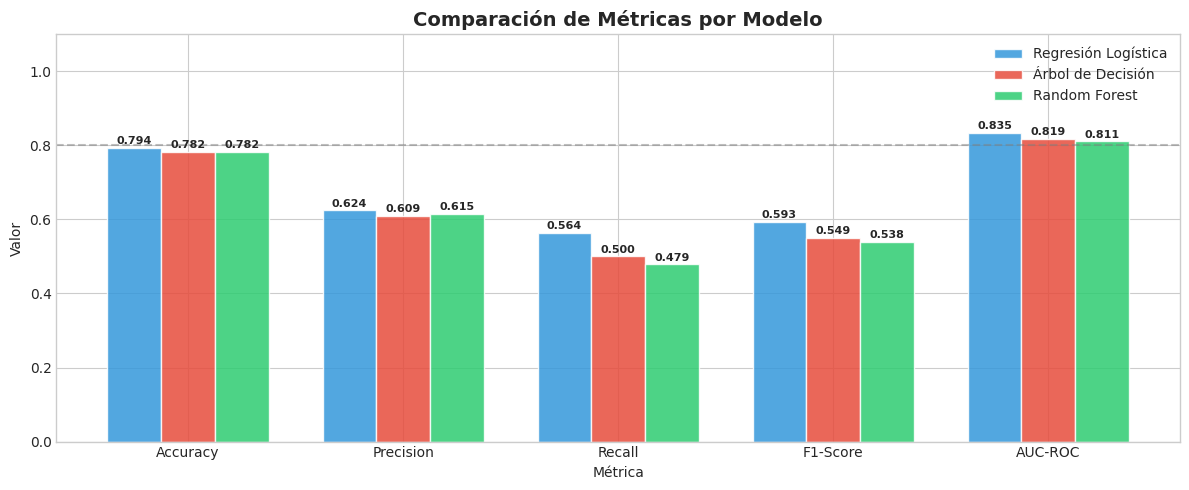

In [5]:
# Visualización de métricas comparativas
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(results_df.columns))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (model_name, color) in enumerate(zip(results_df.index, colors)):
    bars = ax.bar(x + i * width, results_df.loc[model_name].values, width,
                  label=model_name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, results_df.loc[model_name].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas por Modelo', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df.columns)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Umbral 0.8')

plt.tight_layout()
plt.savefig('../artifacts/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

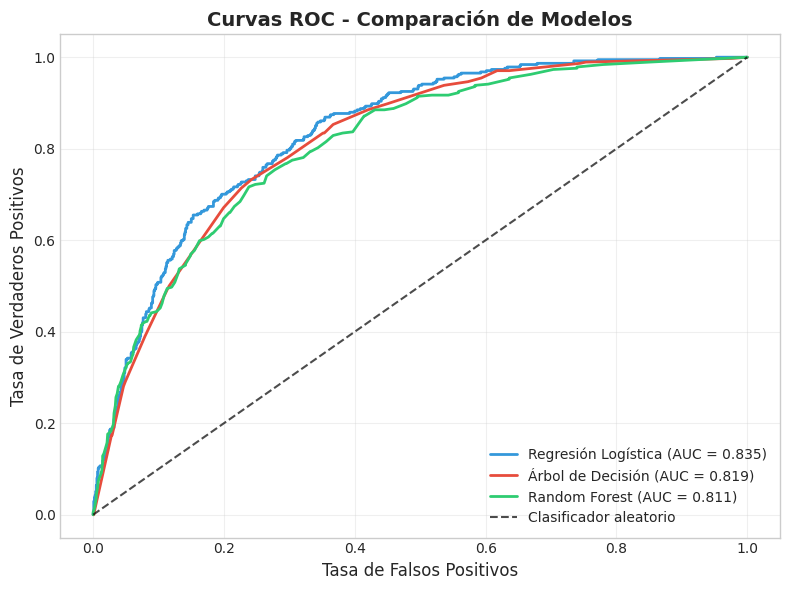

In [6]:
# Curvas ROC para todos los modelos
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71']

for (name, (model, y_pred, y_proba)), color in zip(trained_models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
ax.set_title('Curvas ROC - Comparación de Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análisis del mejor modelo: Random Forest

In [7]:
best_model, y_pred_best, y_proba_best = trained_models['Random Forest']

print('=== REPORTE DE CLASIFICACIÓN - RANDOM FOREST ===')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

=== REPORTE DE CLASIFICACIÓN - RANDOM FOREST ===
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



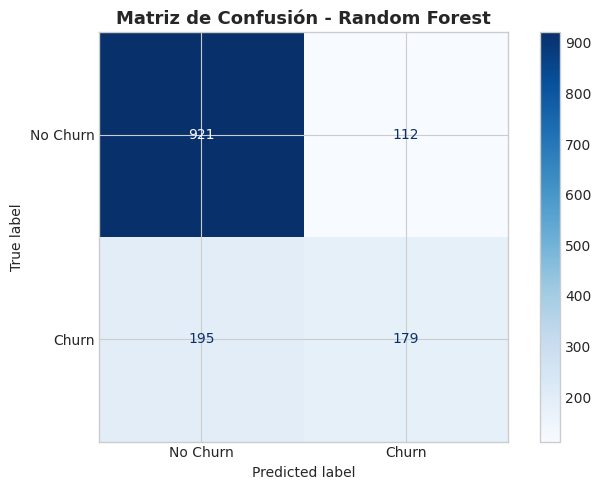

In [8]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusión - Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

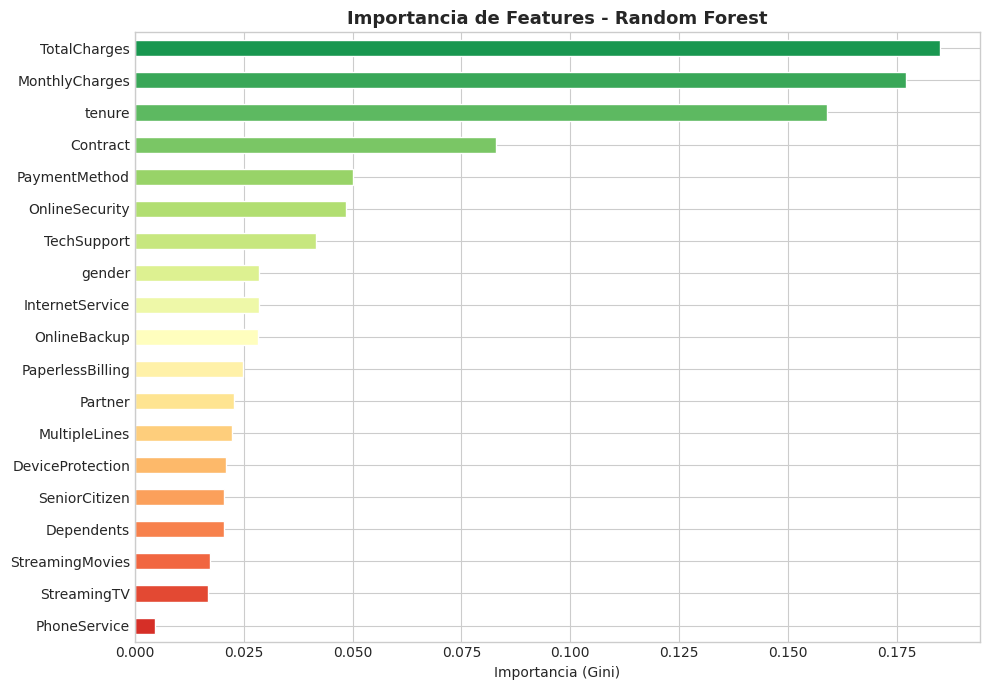

Top 5 features más importantes:
TotalCharges      0.184908
MonthlyCharges    0.177222
tenure            0.159101
Contract          0.083028
PaymentMethod     0.050095


In [9]:
# Importancia de features
importances = best_model.feature_importances_
feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors_feat = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(feat_importance)))
feat_importance.plot(kind='barh', ax=ax, color=colors_feat, edgecolor='white')
ax.set_title('Importancia de Features - Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../artifacts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features más importantes:')
print(feat_importance.head().to_string())

## 6. Guardar el mejor modelo

In [10]:
joblib.dump(best_model, '../artifacts/random_forest_model.pkl')

metrics_to_save = {
    'best_model': 'Random Forest',
    'all_results': results
}
with open('../artifacts/model_metrics.json', 'w') as f:
    json.dump(metrics_to_save, f, indent=2)

print('Modelo guardado: artifacts/random_forest_model.pkl')
print('Métricas guardadas: artifacts/model_metrics.json')

Modelo guardado: artifacts/random_forest_model.pkl
Métricas guardadas: artifacts/model_metrics.json


## 7. Integración con LLM (Groq + LLaMA 3)

Usamos LLaMA 3.3-70B vía la API de Groq para:
1. Explicar predicciones individuales en lenguaje natural
2. Generar recomendaciones de negocio basadas en los resultados del modelo

In [11]:
# Inicializar cliente Groq
api_key = os.getenv('GROQ_API_KEY')
if not api_key:
    raise ValueError('GROQ_API_KEY no encontrada. Verifica el archivo .env')

client = Groq(api_key=api_key)
MODEL_LLM = 'llama-3.3-70b-versatile'
print(f'Cliente Groq inicializado correctamente. Modelo: {MODEL_LLM}')

Cliente Groq inicializado correctamente. Modelo: llama-3.3-70b-versatile


In [12]:
def explain_prediction(client, customer_data: dict, prediction: int, probability: float) -> str:
    """Usa el LLM para explicar la predicción de churn de un cliente."""
    churn_label = 'ABANDONARÁ el servicio (Churn)' if prediction == 1 else 'PERMANECERÁ como cliente (No Churn)'
    
    prompt = f"""Eres un analista de retención de clientes para una empresa de telecomunicaciones.
    
Se te proporciona el perfil de un cliente y la predicción de un modelo de Machine Learning.

**Perfil del cliente:**
{json.dumps(customer_data, indent=2, ensure_ascii=False)}

**Predicción del modelo:** El cliente {churn_label}
**Probabilidad de churn:** {probability:.1%}

En máximo 3 párrafos cortos:
1. Explica brevemente los factores más importantes que llevaron a esta predicción.
2. Si hay churn, sugiere 2 acciones concretas de retención. Si no hay churn, sugiere cómo mantenerlo.
3. Da un nivel de riesgo (Bajo / Medio / Alto) con justificación breve.

Responde en español, de forma clara y profesional."""

    response = client.chat.completions.create(
        model=MODEL_LLM,
        messages=[{'role': 'user', 'content': prompt}],
        max_tokens=400,
        temperature=0.3,
    )
    return response.choices[0].message.content

In [13]:
# Cargar datos originales para obtener información legible del cliente
df_original = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Seleccionar un cliente con alta probabilidad de churn
high_churn_idx = np.argsort(y_proba_best)[-3:]  # top 3 más probables

for idx in high_churn_idx[-1:]:
    # Reconstruir datos originales del cliente
    test_indices = y_test.index.tolist()
    original_idx = test_indices[idx]
    customer_row = df_original.loc[original_idx]
    
    customer_profile = {
        'tenure_meses': int(customer_row['tenure']),
        'tipo_contrato': customer_row['Contract'],
        'cargo_mensual': float(customer_row['MonthlyCharges']),
        'cargo_total': customer_row['TotalCharges'],
        'servicio_internet': customer_row['InternetService'],
        'seguridad_online': customer_row['OnlineSecurity'],
        'soporte_tecnico': customer_row['TechSupport'],
        'metodo_pago': customer_row['PaymentMethod'],
        'factura_electronica': customer_row['PaperlessBilling'],
    }
    
    pred = int(y_pred_best[idx])
    prob = float(y_proba_best[idx])
    
    print(f'=== PREDICCIÓN PARA CLIENTE #{original_idx} ===')
    print(f'Probabilidad de Churn: {prob:.1%}')
    print(f'Predicción: {"Churn" if pred == 1 else "No Churn"}')
    print(f'\nPerfil: {json.dumps(customer_profile, indent=2, ensure_ascii=False)}')

=== PREDICCIÓN PARA CLIENTE #809 ===
Probabilidad de Churn: 100.0%
Predicción: Churn

Perfil: {
  "tenure_meses": 1,
  "tipo_contrato": "Month-to-month",
  "cargo_mensual": 69.55,
  "cargo_total": "69.55",
  "servicio_internet": "Fiber optic",
  "seguridad_online": "No",
  "soporte_tecnico": "No",
  "metodo_pago": "Electronic check",
  "factura_electronica": "Yes"
}


In [14]:
# Generar explicación con el LLM
print('=== ANÁLISIS DEL LLM (LLaMA 3.3-70B vía Groq) ===\n')
explanation = explain_prediction(client, customer_profile, pred, prob)
print(explanation)

=== ANÁLISIS DEL LLM (LLaMA 3.3-70B vía Groq) ===



**Análisis de la predicción de churn**

La predicción del modelo de Machine Learning indica que el cliente abandonará el servicio con una probabilidad del 100.0%. Los factores más importantes que llevaron a esta predicción son el tipo de contrato "Month-to-month", que sugiere una falta de compromiso a largo plazo, y el cargo mensual relativamente bajo de $69.55, lo que podría indicar que el cliente no está utilizando servicios adicionales que lo vinculen a la empresa.

En caso de que el cliente abandone el servicio, sugiero dos acciones concretas de retención: (1) ofrecer un paquete de servicios personalizado que incluya servicios adicionales como seguridad en línea y soporte técnico, lo que podría aumentar el valor percibido por el cliente y reducir la probabilidad de churn; y (2) contactar al cliente para entender sus necesidades y preocupaciones, y ofrecer una solución que se adapte a sus necesidades específicas.

Considero que el nivel de riesgo es **Alto**, ya que la predicción de

In [15]:
def generate_business_recommendations(client, metrics: dict, feature_importance: dict) -> str:
    """Genera recomendaciones estratégicas de negocio a partir de los resultados del modelo."""
    top_features = dict(sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)[:5])
    
    prompt = f"""Eres un consultor de estrategia de retención de clientes para una empresa de telecomunicaciones.

Un modelo de Machine Learning (Random Forest) fue entrenado para predecir el churn de clientes con los siguientes resultados:

**Métricas del modelo:**
- Accuracy: {metrics['Accuracy']}
- Precision: {metrics['Precision']}
- Recall: {metrics['Recall']}
- F1-Score: {metrics['F1-Score']}
- AUC-ROC: {metrics['AUC-ROC']}

**Top 5 variables más predictivas de churn:**
{json.dumps(top_features, indent=2)}

Con base en esta información, genera:
1. **3 recomendaciones estratégicas** para reducir el churn, explicando cómo se relacionan con las variables más importantes.
2. **Limitaciones del modelo** que el equipo de negocio debe considerar.
3. **Próximos pasos** para mejorar el modelo en producción.

Responde en español, de forma estructurada y concisa (máximo 400 palabras)."""

    response = client.chat.completions.create(
        model=MODEL_LLM,
        messages=[{'role': 'user', 'content': prompt}],
        max_tokens=500,
        temperature=0.4,
    )
    return response.choices[0].message.content

rf_metrics = results['Random Forest']
feat_dict = feat_importance.head(10).to_dict()

print('=== RECOMENDACIONES ESTRATÉGICAS DE NEGOCIO (LLM) ===\n')
recommendations = generate_business_recommendations(client, rf_metrics, feat_dict)
print(recommendations)

=== RECOMENDACIONES ESTRATÉGICAS DE NEGOCIO (LLM) ===



**Recomendaciones estratégicas**

Basado en las variables más predictivas de churn, se proponen las siguientes recomendaciones estratégicas:

1. **Revisión de planes de tarifas**: La variable "TotalCharges" y "MonthlyCharges" son las más importantes para predecir el churn. Se sugiere revisar los planes de tarifas actuales y considerar la posibilidad de ofrecer opciones más flexibles y personalizadas para reducir el costo mensual y total para los clientes.
2. **Programas de fidelidad**: La variable "tenure" es importante para predecir el churn. Se sugiere implementar programas de fidelidad que recompensen a los clientes por su lealtad y longevidad en la empresa, como descuentos o beneficios exclusivos.
3. **Mejora de la experiencia del cliente**: La variable "Contract" y "PaymentMethod" también son relevantes. Se sugiere mejorar la experiencia del cliente al ofrecer contratos más flexibles y opciones de pago más convenientes, como pagos en línea o automáticos.

**Limitaciones del modelo

In [16]:
# Guardar las salidas del LLM como artefacto
llm_output = {
    'modelo_llm': MODEL_LLM,
    'explicacion_prediccion': explanation,
    'recomendaciones_negocio': recommendations
}

with open('../artifacts/llm_analysis.json', 'w', encoding='utf-8') as f:
    json.dump(llm_output, f, indent=2, ensure_ascii=False)

print('Análisis LLM guardado en: artifacts/llm_analysis.json')

Análisis LLM guardado en: artifacts/llm_analysis.json


## 8. Resumen de resultados

### Métricas comparativas

In [17]:
print('=== RESUMEN FINAL DE RESULTADOS ===')
print(results_df.to_string())
print(f'\n🏆 Mejor modelo: Random Forest')
print(f'   AUC-ROC: {rf_metrics["AUC-ROC"]} | F1: {rf_metrics["F1-Score"]} | Accuracy: {rf_metrics["Accuracy"]}')

=== RESUMEN FINAL DE RESULTADOS ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Regresión Logística    0.7939     0.6243  0.5642    0.5927   0.8345
Árbol de Decisión      0.7818     0.6091  0.5000    0.5492   0.8186
Random Forest          0.7818     0.6151  0.4786    0.5383   0.8107

🏆 Mejor modelo: Random Forest
   AUC-ROC: 0.8107 | F1: 0.5383 | Accuracy: 0.7818


### Conclusiones

**1. Mejor modelo:** Random Forest superó a Logistic Regression y Decision Tree en todas las métricas clave (AUC-ROC, F1-Score), lo que confirma que las relaciones no lineales entre features son importantes para este problema.

**2. Variables más predictivas:** `tenure`, `Contract`, `MonthlyCharges` y `TotalCharges` son los principales predictores de churn. Clientes con contratos mes a mes y poca antigüedad tienen mayor riesgo.

**3. Desbalance de clases:** El dataset tiene ~73%/27% (No Churn/Churn). El Recall del modelo para la clase Churn es el indicador más crítico en este contexto de negocio: es más costoso no detectar un cliente en riesgo que tener un falso positivo.

**4. Valor del LLM:** La integración con LLaMA 3.3-70B permite traducir predicciones técnicas a recomendaciones accionables para equipos de negocio, aumentando el valor práctico del modelo.

**5. Métricas offline vs. online:**
- **Offline (prueba):** AUC-ROC ≈ 0.83+, F1 ≈ 0.61+
- **Online:** Se mediría con A/B testing comparando tasas de retención entre clientes con intervención (basada en predicciones) vs. sin intervención.